In [2]:
import CSV
using DataFrames
import PyPlot as plt
import Glob
import Statistics, NaNStatistics
import Geodesy
import Dates
import LaTeXStrings
import TiffImages
import FixedPointNumbers
import HDF5
import Colors
using IRQIV
plt.pygui(true) # sets plots to popup instead of inline
Threads.nthreads()
# Use Pkg.develop(path="/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl") to update IRQIV.jl (after pulling from repo)

1

In [3]:
# plt.close()
# impath = raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/GCP_photos/Rec-DeFreesLab_-003354_usGCPs.tif"
# image = plt.imread(impath)
# plt.imshow(image; extent = [1,1344,784,1])
# plt.show()

In [4]:
macpath = raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/5_23_SiteVisit/Georeferencing/Leica/M_CNRD.TXT"
winpath = raw"C:\Users\evanh\Box\Cornell\CACO\2023\5_23_SiteVisit\Georeferencing\Leica\M_CNRD.TXT"
ft_to_m = 0.3048
CNRD_resurvey = CSV.read(macpath, DataFrames.DataFrame) # Total station recorded in survey ft!!
US_GCP_xyz_resurvey = [CNRD_resurvey[2:7,2] CNRD_resurvey[2:7,3] CNRD_resurvey[2:7,4]] .* ft_to_m
DS_GCP_xyz_resurvey = [CNRD_resurvey[8:12,2] CNRD_resurvey[8:12,3] CNRD_resurvey[8:12,4]] .* ft_to_m

# Convert to geospatial coords using GPS data
antenna_csv = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/5_23_SiteVisit/Georeferencing/InertialSense/20230515_173251_base/LOG_SN40107_20230515_173251_0001_DID_GPS1_RTK_POS.csv", DataFrames.DataFrame)
antenna_lla = Geodesy.LLA(Statistics.mean(antenna_csv."lla[0]"), Statistics.mean(antenna_csv."lla[1]"), Statistics.mean(antenna_csv."lla[2]"))
antenna_utm = Geodesy.UTMZ(antenna_lla, Geodesy.wgs84)

# US_GCP_utm_resurvey = US_GCP_xyz_resurvey + [antenna_utm.x antenna_utm.y antenna_utm.z]
US_GCP_utm_resurvey = US_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m
DS_GCP_utm_resurvey = DS_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m

# Set x&y location of all bolts on post 5 to same location (vertically-aligned)
# DS_GCP_utm_resurvey[2, 1:2] = DS_GCP_utm_resurvey[1, 1:2]
# DS_GCP_utm_resurvey[3, 1:2] = DS_GCP_utm_resurvey[1, 1:2]
US_GCP_utm_resurvey

┌ Warning: thread = 1 warning: parsed expected 6 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/evanheberlein/.julia/packages/CSV/OnldF/src/file.jl:578


6×3 Matrix{Float64}:
 411768.0        4.64269e6  -26.8822
 411768.0        4.64269e6  -25.9277
      4.11768e5  4.64269e6  -26.4318
      4.11767e5  4.64269e6  -25.8981
 411767.0        4.64269e6  -26.8825
      4.11766e5  4.64269e6  -26.8944

In [5]:
US_board_o1 = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/CACO_GPS/20220713_163042_US_FOV2_GCPo1/LOG_SN40107_20220713_163042_0001_DID_GPS1_POS.csv", DataFrame)
US_board_o1 = US_board_o1[:,[9, 10, 11, 16]] # lla 1-3 + status (code 0x00000C00 = RTK_FIX according to pg. 138: https://docs.inertialsense.com/user-manual/reference/user_manual_pdf/InertialSenseDocs.pdf)
US_board_o1_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), US_board_o1) 
US_board_o2 = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/CACO_GPS/20220713_165157_US_FOV2_GCPo2/LOG_SN40107_20220713_165157_0001_DID_GPS1_POS.csv", DataFrame)
US_board_o2 = US_board_o2[:,[9, 10, 11, 16]] # lla 1-3 + status (code 0x00000C00 = RTK_FIX according to pg. 138: https://docs.inertialsense.com/user-manual/reference/user_manual_pdf/InertialSenseDocs.pdf)
US_board_o2_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), US_board_o2) 
# o2 did not get to fix
US_board_o1_avg = Statistics.mean.(eachcol(US_board_o1_fix[:,1:3]))
US_board_o1_utm = Geodesy.UTMZ(Geodesy.LLA(US_board_o1_avg[1], US_board_o1_avg[2], US_board_o1_avg[3]), Geodesy.wgs84)
US_board_o1_utm = [US_board_o1_utm.x US_board_o1_utm.y US_board_o1_utm.z]

US_GCP_utm_combined = vcat(US_GCP_utm_resurvey, US_board_o1_utm[1,:]')

US_bo1_file = "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003253.ats"
US_bo1_img = IRQIV.LoadATSImageSequence(US_bo1_file, 1, 2022)

# plt.close("all")
# fig,ax = plt.subplots()
# im = ax.imshow(US_bo1_img[:,:,1], vmin=8700, vmax=11800)
# plt.show()

┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415


IRQIV.FLIRATSFiles.ATSSequence([0x3130 0x30fe … 0x31ed 0x31fe; 0x313d 0x312c … 0x31ec 0x31fa; … ; 0x317f 0x3181 … 0x321e 0x322a; 0x318c 0x317a … 0x3215 0x3232;;;], UInt16[0x0014 0x0309 … 0x3130 0x3130], IRQIV.FLIRATSFiles.ATSFileMetadata("Rec-DeFreesLab_-003253.ats", "/Volumes/ETH_4TB/CNRD_IR", "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003253.ats", "003253", 0.01, 60453, 3329, 784, 1344, 2688, 2107392, 3200, NaN, Dates.DateTime("2022-07-13T15:38:00.500"), "2022-07-13 15:38:00"))

In [6]:
# Thermistor data 
thermpath = "/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Thermistor/P6_CACO_July_2022.txt"
therm = CSV.read(thermpath, delim = ',', skipto = 48, DataFrames.DataFrame)
# psi_to_m_seawater = 0.689475729317831 # not needed and likely incorrect
thermP = therm[:,2]#.*psi_to_m_seawater # water surface elevation from thermistor - in dbar?
# 360 lines per hour, 8640 lines per day
us_therm_cam_offset = (sqrt(9^2-2^2) + 1/3 + 7) * ft_to_m
ds_therm_cam_offset = 209/12*ft_to_m

therm[!,3] = Dates.Date.(therm[!,3], " dd u YYYY")
therm_datetime = Dates.DateTime.(therm[!,3], therm[!,4])
therm = hcat(therm, therm_datetime)
rename!(therm,[:TemperatureC, :PressureM, :Date, :Time, :DateTime])

therm_moved_bool = (therm.Time .== Dates.Time("08:12:00", "HH:MM:SS")) .& (therm.Date .== Dates.Date("2022-07-14", "yyyy-mm-dd"))
therm_moved_idx = findall(x->x==1, therm_moved_bool)
thermZ = us_therm_cam_offset.-thermP[1:therm_moved_idx[]] # vertical offset from camera to thermistor - 
thermZ = append!(thermZ, ds_therm_cam_offset.-thermP[therm_moved_idx[]+1:end])

therm = hcat(therm, thermZ)
rename!(therm, :x1 => :WaterDistanceFromCameraM)

# plt.close("all")
# thermT = string.(therm[:,4])
# plt.plot(thermT[6302:6302+8638], thermP[6302:6302+8638])
# plt.xticks(1:1200:length(thermZ[6302:6302+8638])#, rotation = 45
# )
# plt.xlabel("Time - July 14, 2022")
# plt.ylabel("Thermistor pressure head (m)")
# plt.rc("font",size=24)
# plt.show()

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/evanheberlein/.julia/packages/CSV/OnldF/src/file.jl:578


Row,TemperatureC,PressureM,Date,Time,DateTime,WaterDistanceFromCameraM
,Float64,Float64,Date,Time,DateTime,Float64
1,25.9046,-0.049,2022-07-13,06:30:00,2022-07-13T06:30:00,4.95881
2,25.9042,-0.049,2022-07-13,06:30:10,2022-07-13T06:30:10,4.95881
3,25.9081,-0.049,2022-07-13,06:30:20,2022-07-13T06:30:20,4.95881
4,25.9097,-0.049,2022-07-13,06:30:30,2022-07-13T06:30:30,4.95881
5,25.9091,-0.049,2022-07-13,06:30:40,2022-07-13T06:30:40,4.95881
6,25.9086,-0.049,2022-07-13,06:30:50,2022-07-13T06:30:50,4.95881
7,25.9086,-0.049,2022-07-13,06:31:00,2022-07-13T06:31:00,4.95881
8,25.9087,-0.049,2022-07-13,06:31:10,2022-07-13T06:31:10,4.95881
9,25.9077,-0.049,2022-07-13,06:31:20,2022-07-13T06:31:20,4.95881


In [7]:
# ChatGPT function to find nearest thermistor times to each
function find_nearest_time_indices(irregular_times, regular_times)
    nearest_indices = [argmin(abs.(time .- regular_times)) for time in irregular_times]
    return nearest_indices
end

find_nearest_time_indices (generic function with 1 method)

In [8]:
# Global camera parameters
fl = 1214.2857142857144 # In pixels - from Seth
include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl")
Camera = IRQIV.FLIR_SC8303_17mm
ι = IRQIV.IntrinsicCalibrationParameters(Camera)

IntrinsicCalibrationParameters(672.5, 392.5, 1.0086485610865155, 1.0, 1.4e-5, [1.0, 3.0, 5.0], [0.020522291524825344, -3.156396095419575e-8, -8.859823756718999e-14])

In [9]:
# Camera location calibration setup - UPSTREAM SIDE:
camll_us = [41.931168, -70.064190] # Guess from google maps
camelev_us = sqrt(9^2-2^2)*ft_to_m + (US_GCP_utm_resurvey[1,3] * ft_to_m) # add elevation from bridge deck to elevation of first bolt below deck (~4" off?)
cam_LLA_us = Geodesy.LLA(camll_us[1], camll_us[2], camelev_us)
cam_UTM_us = Geodesy.UTMZ(cam_LLA_us, Geodesy.wgs84)

# Camera angle approximation:
azimuth_us = deg2rad(5) # Guess from google maps
# azimuth_us = deg2rad(5-40) # CONVERGE #1
tilt_us = atan(70/62) # Approx. from photo
# tilt_us = atan(70/62 - deg2rad(55)) # CONVERGE #1
roll_us = atan(20/85) # ''
# roll_us = atan(20/85 + deg2rad(45)) # CONVERGE #1

# Initial guess of camera's extrinsic parameters:
χinitial_us = IRQIV.ExtrinsicCalibrationParameters(azimuth_us, tilt_us, roll_us, fl, cam_UTM_us.x, cam_UTM_us.y, cam_UTM_us.z) # can also play with height
# χinitial = IRQIV.ExtrinsicCalibrationParameters(azimuth_us, tilt_us, roll_us, fl, cam_UTM_us.x-1, cam_UTM_us.y+2, cam_UTM_us.z) # CONVERGE #1

# UTM coordinates of GCPs:
# TrueGCPxyz = [GCPxyz_us[:,1] GCPxyz_us[:,2] GCPzg_us]

# Pixel coordinates of GCPs, before accounting for radial distortion:
DistortedImageGCPuv_us  = [481 535 # 1L
                        270 446 # 1H
                        215 253 # 2L
                        94 188 # 2H
                        174 159 # 3
                        83 43] # 4
                        #474 65] # board o1

## Remove radial distortion from GCP target coordinates:
TrueGCPuv_us = hcat(IRQIV.RemoveRadialDistortion(DistortedImageGCPuv_us[:,1], DistortedImageGCPuv_us[:,2], Camera)...)

# Optionally, load an IR image and plot it in the background:
# FLIR_filename_us = raw"/Volumes/OWC_NVMe_4TB/CNRD_IR/Rec-DeFreesLab_-003310.ats"
# IRimages_us = LoadATSImageSequence(FLIR_filename_us, 1, 2022)
# plt.close("all")
# GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_us, US_GCP_utm_resurvey, χinitial_us, ι, IRimages_us[1])
# plt.show()

6×2 Matrix{Float64}:
 484.531   532.373
 275.196   445.309
 218.964   254.209
  91.733   187.199
 175.407   159.659
  74.8383   38.1611

In [10]:
# Camera location calibration - UPSTREAM SIDE:
dlt_us = IRQIV.DLT(χinitial_us, FLIR_SC8303_17mm)
###############################################################################

TrueGCPxyz_us = US_GCP_utm_resurvey # US_GCP_utm_combined

χcalculated_us = ExtrinsicCalibration(
    TrueGCPuv_us,
    TrueGCPxyz_us,
    χinitial_us,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)
# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_us)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated_us)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated_us)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_us, x) - getfield(χcalculated_us, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_us, x) - getfield(χcalculated_us, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_us, x) - getfield(χcalculated_us, x))")
    end
end

# plt.close("all")
# GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_us, TrueGCPxyz_us, χcalculated_us, ι, IRimages_us[1])
# plt.show()

Finished extrinsic calibration:, 29 iterations, max(|ε|)=1e-10, rms(ε₁-ε₀)=4e-11


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:15


ExtrinsicCalibrationParameters
  φ: Float64 0.08726646259971647
  τ: Float64 0.8459301831795555
  σ: Float64 0.23109066719589708
  f: Float64 1214.2857142857144
  x_c: Float64 411770.8466259552
  y_c: Float64 4.6426814979640795e6
  z_c: Float64 -5.519070868946805
dump(χinitial_us) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 -0.4230688125844572
  τ: Float64 0.41116895749496685
  σ: Float64 0.8402353194723755
  f: Float64 801.5885702709454
  x_c: Float64 411767.84929119097
  y_c: Float64 4.642685324157672e6
  z_c: Float64 -24.487350688725805
dump(χcalculated_us) = nothing
φ diff (degrees) -  29.240057404700607
τ diff (degrees) -  24.909983327661614
σ diff (degrees) -  -34.901417688406305
f diff -  412.69714401476904
x_c diff (meters) -  2.9973347642226145
y_c diff (meters) -  -3.8261935925111175
z_c diff (meters) -  18.968279819779


┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:18
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:22


In [11]:
# Upstream IRQIV averaging
# Need to store: discharge estimate, time vector

# Subwindow dimensions remain constant
const M=80 # subwindow dims - horiz, N = vert.
const N=80
const rhoI = 80 # how far away to search (+/-) - i=short side, j= long side
const rhoJ = 80 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344] # Image dims: 784 x 1344
DtFrames = 1                    # Δt, frames (ATS 3116 is at 10Hz)
data_output_rate_frames = 150    # difference between I1 sequence, frames - time sep of output
nImagePairs = 20 # can set to inf - all frames in file
Nfiles = 40 # Set number of files to average over

# Load IR images:
I1inds = range(1, step=data_output_rate_frames, length=nImagePairs)
I2inds = I1inds .+ DtFrames

# Original subwindow code:
subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)), 
                                    (M+rhoJ):M:(Img_dims[2]-(M+rhoJ+1))))
# Restrict subwindows to only area around shadow/ROI (problematic bc search radius not incorporated): 
# subwincorners = CartesianIndices(( (N+rhoI):N:(size(I1images,1)-(N+rhoI+1)), 
#                                      (us_shadow_start[1]-M-rhoJ):M:(us_shadow_end[1]+(M+rhoJ+1))))
# subwin_inds_grid = cat(getindex.(subwincorners,2), getindex.(subwincorners,1))

###############################################################################################
# Creating custom subwindows US - look at shadow from first file after tide turns around (3349)
us_shadow_start = [182,1] # [u,v]
us_shadow_end = [764,784] # [u,v]
us_shadow_ror = (us_shadow_end[2] - us_shadow_start[2])/(us_shadow_end[1] - us_shadow_start[1]) # rise over run - v/u ratio
us_transect_start_u = us_shadow_start[1] + M + rhoJ
us_transect_start_v = us_shadow_start[2] + N + rhoI # First point in vertical pixels - edge of image + search radius + subwindow size
# us_transect_start_u = us_shadow_start[1] + round(us_transect_start_v/us_shadow_ror) + M + rhoJ # First pt in horizontal pixels - edge of shadow + 
[us_transect_start_u, us_transect_start_v]
us_transect_end_v = us_shadow_end[2] - N - rhoI

# Find angle of shadow (from vertical)
us_shadow_theta = atan(1/us_shadow_ror)

# Select subwindows for quantification
subwin_inds_vec = hcat(vec(getindex.(subwincorners,2)), vec(getindex.(subwincorners,1))) # [u, v]

# Filter by row in v coordinate :
subwin_v_coords = getindex.(subwincorners,1)[:,1] # vector of subwindow v pixel coordinates (vertical)
subwin_u_coords = getindex.(subwincorners,2)[1,:] # vector of subwindow u pixel coordinates (horizontal)
subwin_diag_u_inds = zeros(length(subwin_v_coords))
subwin_diag_u_inds[1] = findfirst(subwin_u_coords .>= us_transect_start_u) # index in of first subwindow located >= from transect start at top of image

 # find u coordinate for each subwindow along diagonal to have one subwindow in each row of v
 subwin_diag_u = subwin_u_coords[Int(subwin_diag_u_inds[1])] # find starting u coordinate
for i = 2:length(subwin_v_coords) # for every row in v 
    subwin_diag_u = subwin_diag_u + N/us_shadow_ror # from previous u coordinate, go 
    subwin_diag_u_inds[i] = findfirst(subwin_u_coords .>= subwin_diag_u)
end

subwin_diag_v_inds = vec(1:length(subwin_v_coords))

# Create mask to isolate indices of subwindows of interest
subwin_mask = zeros(size(subwincorners))
replace!(subwin_mask, 0=>NaN)

for u = 1:size(subwin_mask,2)
    for v = 1:size(subwin_mask,1)
        u_ind = subwin_diag_u_inds[v] # 15
        v_ind = subwin_diag_v_inds[v]
        if u == u_ind && v == v_ind # find subwindow indices in 2d arrays
            subwin_mask[v,u] = 1
        else
        end
    end
end

# Create empty vectors for loop analysis
gate_width_us = (97*2+89)/12*ft_to_m # m, 2 97' gates & 1 89" gate on us side
Q_op_vec_us = Any[]# Save Q est for each operation
TS_op_vec_us = Any[]
img_edge_xy = [0.0 0.0]

# For file-averaged operation:
# Q_est_vec_us = fill(NaN, Nfiles)
# ts_inds_us = fill(NaN, Nfiles)

for fi = 1:Nfiles
    filenum = fi + 3347 # start at 3348
    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(filenum) * ".ats")
    ats_year = 2022
    @assert isfile(FLIR_filename)
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)

    # Remove image pairs when at least one image took place during NUC (calibration)
    # mode:
    if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
        nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
        I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
        I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    end

    # Initialize MQD calculation:
    MQD_variables = initialize_MQD(I1images,
                                I2images,
                                subwincorners,
                                N, M,
                                rhoI, rhoJ)                              

    # Perform the MQD analysis:
    subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
        I1images, I2images, subwincorners, MQD_variables)
    #, MQD_parameters);

    ATS_file_time = extrema(IRQIV.ats_ts(I1images))
    therminds_file = findall(x->x>ATS_file_time[1] && x<ATS_file_time[2], therm.DateTime)
    WSE_mean_ATS = χcalculated_us.z_c  - mean(therm.WaterDistanceFromCameraM[therminds_file])

    # Upstream georectification
    displacement_x, displacement_y, centroid_x_origin, centroid_y_origin = pixel2physical_displacements(subwincorners, 
                                                                                                        subpix_shifts_i, 
                                                                                                        subpix_shifts_j, 
                                                                                                        M, N, 
                                                                                                        WSE_mean_ATS,
                                                                                                        dlt_us)                                                                                            

    # File-averaged code                                                                                                    # displacement_x_mean = dropdims(
    #     NaNStatistics.nanmean(displacement_x[:,:,:], dims=3), dims=3)
    # displacement_y_mean = dropdims(
    #     NaNStatistics.nanmean(displacement_y[:,:,:], dims=3), dims=3)
    # displacement_x_mean_masked = displacement_x_mean .* subwin_mask
    # displacement_y_mean_masked = displacement_y_mean .* subwin_mask
    # displacement_mean_masked = hypot.(displacement_x_mean_masked, displacement_y_mean_masked)
    # displacement_alpha = atan.(displacement_y_mean_masked./displacement_x_mean_masked)
    # displacement_normal = displacement_mean_masked .* cos.(displacement_alpha .- us_shadow_theta)

    # mean_vel = NaNStatistics.nanmean(displacement_normal) / dt # m/s 
    # Q_est_vec_us[fi] = gate_width_us * (0.85 * mean_vel) * mean(therm.PressureM[therminds])
    #ts_ind = Int(round(length(IRQIV.ats_ts(I1images))/2))
    # ts_inds_us[fi] = last(therminds)

    # Create time vector from each ATS file metadata
    dt_vec = (IRQIV.ats_ts(I2images) .- IRQIV.ats_ts(I1images)) # ats_ts = timestamp, should give consistent dt
    dt_vec = [Dates.value(x) for x in dt_vec]
    dt = dt_vec ./ 1000 # convert ms to s 
    
    # Update: instantaneous code
    displacement_x_masked = displacement_x .* subwin_mask
    displacement_y_masked = displacement_y .* subwin_mask
    inst_disp = hypot.(displacement_x_masked, displacement_y_masked)
    inst_disp_alpha = atan.(displacement_y_masked./displacement_x_masked)
    inst_disp_field_normal = inst_disp .* cos.(inst_disp_alpha .- us_shadow_theta)
    inst_vel_normal = dropdims(NaNStatistics.nanmean(inst_disp_field_normal, dims = (1,2)), dims = (1,2)) ./ dt

    therminds_nearest = find_nearest_time_indices(IRQIV.ats_ts(I1images), therm.DateTime)
    append!(TS_op_vec_us, therm.DateTime[therminds_nearest])

    opstart = fi*nImagePairs-nImagePairs+1
    opend = fi*nImagePairs
    inst_Q = (inst_vel_normal * 0.85 * gate_width_us) .* therm.PressureM[therminds_nearest]
    append!(Q_op_vec_us, inst_Q)

    # Store image physical dimensions for scaling:
    img_edge_xy[1] = centroid_x_origin[end,1] - centroid_x_origin[end,end] # Distance between physical locations of bottom l/r subwindows (bottom edge b/w abutments)
    img_edge_xy[2] = centroid_y_origin[end,1] - centroid_y_origin[end,end] # "

    # plt.close("all")
    # fig,axs = plt.subplots()
    # q = axs.quiver(centroid_x_origin, centroid_y_origin, displacement_x_mean, displacement_y_mean, angles="xy")
    # S = axs.scatter(UTM_us_S[1], UTM_us_S[2])
    # No = axs.scatter(UTM_us_N[1], UTM_us_N[2])
    # cam = axs.scatter(χcalculated_us.x_c, χcalculated_us.y_c)
    # plt.show()
end
# ATS_tst_vec_us = therm.DateTime[Int.(ts_inds_us)]

# Scaling w/ UTM coords of gate
UTM_us_S = [411771, 4642684]
UTM_us_N = [411766, 4642694]
ground_UTM_width = hypot(UTM_us_S[2]-UTM_us_N[2], UTM_us_S[1]-UTM_us_N[1]) # Hypotnuse between two rock abutments on either side of image
reproj_UTM_width = hypot(img_edge_xy[1], img_edge_xy[2]) # Distance
US_scaling_factor = ground_UTM_width / reproj_UTM_width
Q_op_vec_us_scaled = Q_op_vec_us.*US_scaling_factor

# Filter NaNs from initial estimates, appears unnecessary
# deleteat!(TS_op_vec_us, Q_op_vec_us .== NaN)

# plt.close("all")
# plt.plot(TS_op_vec_us, Q_op_vec_us_scaled)
# plt.show()

5.0%┣██▏                                        ┫ 1/20 [00:03<Inf:Inf, InfGs/it]
10.0%┣████▊                                          ┫ 2/20 [00:04<01:10, 4s/it]
15.0%┣███████                                        ┫ 3/20 [00:04<00:37, 2s/it]
20.0%┣█████████▍                                     ┫ 4/20 [00:05<00:25, 2s/it]
25.0%┣███████████▊                                   ┫ 5/20 [00:05<00:19, 1s/it]
30.0%┣██████████████                                 ┫ 6/20 [00:05<00:15, 1s/it]
35.0%┣████████████████▌                              ┫ 7/20 [00:06<00:13, 1it/s]
40.0%┣██████████████████▉                            ┫ 8/20 [00:06<00:11, 1it/s]
45.0%┣█████████████████████▏                         ┫ 9/20 [00:07<00:09, 1it/s]
50.0%┣███████████████████████                       ┫ 10/20 [00:07<00:08, 1it/s]
55.0%┣█████████████████████████▎                    ┫ 11/20 [00:07<00:07, 1it/s]
60.0%┣███████████████████████████▋                  ┫ 12/20 [00:08<00:06, 1it/s]
65.0%┣██████████████████████

Performance stats (MQD loop only)
time [s]                    11.416725792
subwins/s             136.64162811838165
allocations [GB]                     3.1
allocations [MB/subwin]               39.73
time [m]                            0.19
total n subwindows                  1560
n image pairs                         20
n subwindows in FOV                   78
size(subwindows)                 (6, 13)
M, N                            (80, 80)
rhoI, rhoJ                      (80, 80)
allocations [B]               3098913190
allocations [MB]                 3098.91
gc time [s]                  0.349235032
gc stats            Base.GC_Diff(3098913190, 7906, 1, 7592788, 6294, 8025, 349235032, 66, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     304204 s          0 s     235306 s    1078090 s          0 s
#2  2400 MHz     290724 s          0 s     218587 s    11

5.0%┣██▏                                        ┫ 1/20 [00:00<Inf:Inf, InfGs/it]
10.0%┣████▊                                          ┫ 2/20 [00:00<00:07, 3it/s]
15.0%┣███████                                        ┫ 3/20 [00:01<00:07, 3it/s]
20.0%┣█████████▍                                     ┫ 4/20 [00:01<00:06, 3it/s]
25.0%┣███████████▊                                   ┫ 5/20 [00:02<00:06, 3it/s]
30.0%┣██████████████                                 ┫ 6/20 [00:02<00:06, 3it/s]
35.0%┣████████████████▌                              ┫ 7/20 [00:02<00:05, 3it/s]
40.0%┣██████████████████▉                            ┫ 8/20 [00:03<00:05, 3it/s]
45.0%┣█████████████████████▏                         ┫ 9/20 [00:03<00:04, 3it/s]
50.0%┣███████████████████████                       ┫ 10/20 [00:04<00:04, 3it/s]
55.0%┣█████████████████████████▎                    ┫ 11/20 [00:04<00:04, 3it/s]
60.0%┣███████████████████████████▋                  ┫ 12/20 [00:04<00:03, 2it/s]
65.0%┣██████████████████████

Performance stats (MQD loop only)
time [s]                     8.298655833
subwins/s             187.98225054671937
allocations [GB]                    2.59
allocations [MB/subwin]               33.16
time [m]                            0.14
total n subwindows                  1560
n image pairs                         20
n subwindows in FOV                   78
size(subwindows)                 (6, 13)
M, N                            (80, 80)
rhoI, rhoJ                      (80, 80)
allocations [B]               2586787696
allocations [MB]                 2586.79
gc time [s]                   0.18853679
gc stats            Base.GC_Diff(2586787696, 7880, 0, 58169, 3, 7578, 188536790, 28, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     304219 s          0 s     235330 s    1078147 s          0 s
#2  2400 MHz     290738 s          0 s     218610 s    1109659

┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
50.0%┣█████████████████████▌                     ┫ 1/2 [00:00<Inf:Inf, InfGs/it]
100.0%┣███████████████████████████████████████████████┫ 2/2 [00:00<00:00, 2it/s]


...

5.3%┣██▎                                        ┫ 1/19 [00:00<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:01<00:11, 2it/s]
15.8%┣███████▍                                       ┫ 3/19 [00:01<00:10, 2it/s]
21.1%┣██████████                                     ┫ 4/19 [00:02<00:09, 2it/s]
26.3%┣████████████▍                                  ┫ 5/19 [00:03<00:09, 2it/s]
31.6%┣██████████████▉                                ┫ 6/19 [00:03<00:08, 2it/s]
36.8%┣█████████████████▎                             ┫ 7/19 [00:04<00:08, 2it/s]
42.1%┣███████████████████▉                           ┫ 8/19 [00:04<00:07, 2it/s]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:05<00:06, 2it/s]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:06<00:06, 2it/s]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:06<00:05, 2it/s]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:07<00:04, 2it/s]
68.4%┣██████████████████████

Performance stats (MQD loop only)
time [s]                    11.890855584
subwins/s             124.63358835121481
allocations [GB]                    2.46
allocations [MB/subwin]               31.51
time [m]                             0.2
total n subwindows                  1482
n image pairs                         19
n subwindows in FOV                   78
size(subwindows)                 (6, 13)
M, N                            (80, 80)
rhoI, rhoJ                      (80, 80)
allocations [B]               2457448720
allocations [MB]                 2457.45
gc time [s]                  0.150036709
gc stats            Base.GC_Diff(2457448720, 7486, 0, 55302, 3, 6070, 150036709, 4, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     304661 s          0 s     235885 s    1081018 s          0 s
#2  2400 MHz     291156 s          0 s     219118 s    1112604 

11.1%┣████▊                                      ┫ 1/9 [00:00<Inf:Inf, InfGs/it]
22.2%┣██████████▊                                     ┫ 2/9 [00:01<00:04, 2it/s]
33.3%┣████████████████                                ┫ 3/9 [00:01<00:04, 2it/s]
44.4%┣█████████████████████▍                          ┫ 4/9 [00:02<00:03, 2it/s]
55.6%┣██████████████████████████▊                     ┫ 5/9 [00:02<00:02, 2it/s]
66.7%┣████████████████████████████████                ┫ 6/9 [00:03<00:02, 2it/s]
77.8%┣█████████████████████████████████████▍          ┫ 7/9 [00:04<00:01, 2it/s]
88.9%┣██████████████████████████████████████████▊     ┫ 8/9 [00:04<00:01, 2it/s]
100.0%┣███████████████████████████████████████████████┫ 9/9 [00:05<00:00, 2it/s]


Performance stats (MQD loop only)
time [s]                     5.715002625
subwins/s             122.83458924920441
allocations [GB]                    1.16
allocations [MB/subwin]               14.92
time [m]                             0.1
total n subwindows                   702
n image pairs                          9
n subwindows in FOV                   78
size(subwindows)                 (6, 13)
M, N                            (80, 80)
rhoI, rhoJ                      (80, 80)
allocations [B]               1164059752
allocations [MB]                 1164.06
gc time [s]                      0.10455
gc stats            Base.GC_Diff(1164059752, 3546, 0, 26125, 3, 3349, 104550000, 2, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     304664 s          0 s     235892 s    1081066 s          0 s
#2  2400 MHz     291161 s          0 s     219124 s    1112652 

739-element Vector{Float64}:
  0.45690157718650615
  0.35028884835547736
  0.6954521341442221
  0.8073885657034329
  0.40900109688968694
  0.37406143272997294
  0.7844254873378564
  0.6099774247522396
  0.031934657970857
  0.4651518567374893
  ⋮
 10.891003118012465
  6.569838530867254
  6.84233713795465
  7.845886889338183
  5.6901407168296645
  7.153626295101849
  7.256437910271699
  7.3595875514375315
  4.914096229390442

In [12]:
# Incorporate board georef on DOWNSTREAM side:
DS_board_o1 = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/CACO_GPS/20220714_201935_DS_GCPo1/LOG_SN40107_20220714_201935_0001_DID_GPS1_POS.csv", DataFrame)
DS_board_o1 = DS_board_o1[:,[9, 10, 11, 16]] # lla 1-3 + status (code 0x00000C00 = RTK_FIX according to pg. 138: https://docs.inertialsense.com/user-manual/reference/user_manual_pdf/InertialSenseDocs.pdf)
DS_board_o1_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o1) # from https://discourse.julialang.org/t/better-way-to-filter-strings-from-dataframe/88012
DS_board_o4 = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/CACO_GPS/20220714_210002_DS_GCPo4/LOG_SN40107_20220714_210002_0001_DID_GPS1_POS.csv", DataFrame)
DS_board_o4 = DS_board_o4[:,[9, 10, 11, 16]] 
DS_board_o4_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o4) 
DS_board_o5 = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/CACO_GPS/20220714_211156_DS_GCPo5/LOG_SN40107_20220714_211156_0001_DID_GPS1_POS.csv", DataFrame)
DS_board_o5 = DS_board_o5[:,[9, 10, 11, 16]] 
DS_board_o5_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o5) 

# o4 & o5 did not get to RTK_FIX but still look very steady - average!
# plt.close("all")
# plt.plot(DS_board_o1_fix[:,1])
# #plt.plot(DS_board_o1_fix[:,2])
# #plt.plot(DS_board_o1_fix[:,3])
# plt.plot(DS_board_o4[:,1])
# #plt.plot(DS_board_o4[:,2])
# #plt.plot(DS_board_o4[:,3])
# plt.plot(DS_board_o5[:,1])
# #plt.plot(DS_board_o5[:,2])
# #plt.plot(DS_board_o5[:,3])
# plt.show()

# Check drift of non-fix GPS 
maximum(DS_board_o4[:,1]) - minimum(DS_board_o4[:,1])
maximum(DS_board_o4[:,2]) - minimum(DS_board_o4[:,2])
maximum(DS_board_o4[:,3]) - minimum(DS_board_o4[:,3])
maximum(DS_board_o5[:,1]) - minimum(DS_board_o5[:,1])
maximum(DS_board_o5[:,2]) - minimum(DS_board_o5[:,2])
maximum(DS_board_o5[:,3]) - minimum(DS_board_o5[:,3])
# Drift is minimal in x/y but large in z

# Compare averages/minimums
DS_board_o1_avg = Statistics.mean.(eachcol(DS_board_o1_fix[:,1:3]))
DS_board_o4_avg = Statistics.mean.(eachcol(DS_board_o4[:,1:3]))
DS_board_o5_avg = Statistics.mean.(eachcol(DS_board_o5[:,1:3]))
DS_board_o5_avg[3] = minimum(DS_board_o5[:,3])
dump(DS_board_o1_avg[3])
dump(DS_board_o4_avg[3])
dump(DS_board_o5_avg[3])
# o5 minimum is closer to mean of o1 & o4, numbers look reasonable relative to DS_GCP_utm_resurvey

# Convert LLA to UTM
DS_board_o1_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o1_avg[1], DS_board_o1_avg[2], DS_board_o1_avg[3]), Geodesy.wgs84)
DS_board_o4_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o4_avg[1], DS_board_o4_avg[2], DS_board_o4_avg[3]), Geodesy.wgs84)
DS_board_o5_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o5_avg[1], DS_board_o5_avg[2], DS_board_o5_avg[3]), Geodesy.wgs84)
DS_board_utm = [DS_board_o1_utm.x DS_board_o1_utm.y DS_board_o1_utm.z
DS_board_o4_utm.x DS_board_o4_utm.y DS_board_o1_utm.z
DS_board_o5_utm.x DS_board_o5_utm.y DS_board_o1_utm.z]

# Add board GPS to resurvey vector:
DS_GCP_utm_combined = vcat(DS_GCP_utm_resurvey, DS_board_utm[1,:]')

# plt.close("all")
# plt.scatter(DS_GCP_utm_combined[:,1], DS_GCP_utm_combined[:,2])
# plt.show()

Float64 -25.947234686018657
Float64 -26.080654823149864
Float64 -26.143906926736236


6×3 Matrix{Float64}:
      4.11745e5  4.64267e6  -25.1365
      4.11745e5  4.64267e6  -25.5898
      4.11745e5  4.64267e6  -26.0746
      4.11744e5  4.64268e6  -26.2701
 411744.0        4.64268e6  -27.268
      4.11743e5  4.64267e6  -25.9472

In [13]:
# Global camera parameters
fl = 1214.2857142857144 # In pixels - from Seth
include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl")
Camera = IRQIV.FLIR_SC8303_17mm
ι = IRQIV.IntrinsicCalibrationParameters(Camera)

IntrinsicCalibrationParameters(672.5, 392.5, 1.0086485610865155, 1.0, 1.4e-5, [1.0, 3.0, 5.0], [0.020522291524825344, -3.156396095419575e-8, -8.859823756718999e-14])

In [14]:
# Camera location calibration setup - DOWNSTREAM SIDE:
camll_ds = [41.931099, -70.064524] # Guess from Google maps
# Have measurement of camera to deck (?) for US side
camelev_ds = DS_GCP_utm_resurvey[3,3] + 6.5*ft_to_m # Use lower bolt elevation w/ offset - [old: Guess DS camera offset from board GCP elev based on photos]
cam_LLA_ds = Geodesy.LLA(camll_ds[1], camll_ds[2], camelev_ds)
cam_UTM_ds = Geodesy.UTMZ(cam_LLA_ds, Geodesy.wgs84)

# Camera angle approximation:
azimuth_ds = 315 * (pi/180)  # Guess from google maps
tilt_ds = atan(34/120) # atan(120/34)  # Approx. from photo
roll_ds = atan(7/50) # ''

# Initial guess of camera's extrinsic parameters:
χinitial_ds = IRQIV.ExtrinsicCalibrationParameters(azimuth_ds, tilt_ds, roll_ds, fl, cam_UTM_ds.x, cam_UTM_ds.y, cam_UTM_ds.z)
dump(χinitial_ds)

# UTM coordinates of GCPs:
# TrueGCPxyz = [GCPxyz_us[:,1] GCPxyz_us[:,2] GCPzg_us]

# Pixel coordinates of GCPs, before accounting for radial distortion:
# File 3582 can see bolt without grass in the way
DistortedImageGCPuv_ds  = [1255 443 # 5H
                        1200 549 # 5M
                        1155 615 # 5L
                        1257 73 # 6H
                        1278 264 # 6L
                        606 71] # board o1
                        #516 366 # board o4
                        #388 716] # board o5


TrueGCPuv_ds = hcat(IRQIV.RemoveRadialDistortion(DistortedImageGCPuv_ds[:,1], DistortedImageGCPuv_ds[:,2], Camera)...)

# FLIR_filename_ds = joinpath(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO_backup/2022/CNRD_IR/Rec-DeFreesLab_-003447.ats")
# IRimages_ds = LoadATSImageSequence(FLIR_filename_ds, 1, 2022)
# plt.close("all")
# GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_ds, DS_GCP_utm_combined, χinitial_ds, ι, IRimages_ds[1])
# plt.show()

ExtrinsicCalibrationParameters
  φ: Float64 5.497787143782138
  τ: Float64 0.27609701939543646
  σ: Float64 0.13909594148207133
  f: Float64 1214.2857142857144
  x_c: Float64 411743.0601037771
  y_c: Float64 4.642674180709229e6
  z_c: Float64 -24.093384677637545


6×2 Matrix{Float64}:
 1255.36  443.031
 1198.5   548.555
 1152.8   613.988
 1263.39   69.5088
 1280.77  263.412
  607.07   76.1732

In [15]:
# Camera location calibration - DOWNSTREAM SIDE:
dlt_ds = IRQIV.DLT(χinitial_ds, FLIR_SC8303_17mm)
###############################################################################

χcalculated_ds = ExtrinsicCalibration(
    TrueGCPuv_ds,
    DS_GCP_utm_combined,
    χinitial_ds,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)

# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_ds)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated_ds)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated_ds)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x))")
    end
end

# plt.close("all")
# GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_ds, DS_GCP_utm_combined, χcalculated_ds, ι, IRimages_ds[1])
# plt.show()

Finished extrinsic calibration:, 21 iterations, max(|ε|)=5e-10, rms(ε₁-ε₀)=9e-11
ExtrinsicCalibrationParameters
  φ: Float64 5.497787143782138
  τ: Float64 0.27609701939543646
  σ: Float64 0.13909594148207133
  f: Float64 1214.2857142857144
  x_c: Float64 411743.0601037771
  y_c: Float64 4.642674180709229e6
  z_c: Float64 -24.093384677637545
dump(χinitial_ds) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 7.568765838748602
  τ: Float64 2.4790153255891205
  σ: Float64 4.091954296345742
  f: Float64 665.1389085408039
  x_c: Float64 411744.68719201843
  y_c: Float64 4.642674371653791e6
  z_c: Float64 -24.684111562274683
dump(χcalculated_ds) = nothing
φ diff (degrees) -  -118.6583386830895
τ diff (degrees) -  -126.2179215570061
σ diff (degrees) -  -226.4821007467142
f diff -  549.1468057449106
x_c diff (meters) -  -1.6270882413373329
y_c diff (meters) -  -0.19094456173479557
z_c diff (meters) -  0.5907268846371387


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:14
┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:17
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:21


In [16]:
# Test reprojection

FLIR_filename = joinpath(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO_backup/2022/CNRD_IR/Rec-DeFreesLab_-003447.ats")
Img_dims = [784, 1344]
DtFrames = 1                    # Δt
data_output_rate_frames = 150    # difference between I1 sequence, frames - time sep of output
nImagePairs = 20 # can set to inf - all frames in file

# Load IR images:

I1images = LoadATSImageSequence(FLIR_filename, 1, 2022)

ATS_file_time = IRQIV.ats_ts(I1images)
therminds = find_nearest_time_indices(ATS_file_time, therm.DateTime)
WSE_mean_ATS = χcalculated_ds.z_c - therm.WaterDistanceFromCameraM[therminds][1]

RectParams = IRQIV.ImageRectification.calculate_image_rectification(Camera.pixel_resolution, ι, χcalculated_ds, WSE_mean_ATS, interpolated_grid_spacing=0.1)
rectified_image = RectParams(I1images)
plt.close("all")
plt.imshow(rectified_image;extent=RectParams.extent)
plt.show()

┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415


  0.005223 seconds (37.99 k allocations: 3.768 MiB)


2025-05-02 10:06:52.435 julia[76638:2730804] +[IMKClient subclass]: chose IMKClient_Modern
2025-05-02 10:06:52.435 julia[76638:2730804] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [ ]:
# Downstream IRQIV averaging

const M=64 # subwindow dims - horiz, N = vert.
const N=64
const rhoI = 40 # how far away to search (+/-) - i=horiz, j= vert
const rhoJ = 40 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344]
DtFrames = 1                    # Δt
data_output_rate_frames = 150    # difference between I1 sequence, frames - time sep of output
nImagePairs = 20 # can set to inf - all frames in file
Nfiles = 20

# Load IR images:
I1inds = range(1, step=data_output_rate_frames, length=nImagePairs)
I2inds = I1inds .+ DtFrames

subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)),
                                (M+rhoJ):M:(Img_dims[2]-(M+rhoJ+1)) ))

########################################################################################
# Creating custom subwindows DS - look at shadow from first file after tide turns around (3487)
ds_shadow_start = [1260,1] # [u,v]
ds_shadow_end = [1090,784] # [u,v]
ds_shadow_ror = (ds_shadow_end[2] - ds_shadow_start[2])/(ds_shadow_end[1] - ds_shadow_start[1]) # rise over run - v/u ratio
ds_transect_start_u = ds_shadow_start[1] - M - rhoJ # subtract here bc shadow on rhs of image - us it was on lhs
ds_transect_start_v = ds_shadow_start[2] + N + rhoI # First point in vertical pixels - edge of image + search radius + subwindow size
# us_transect_start_u = us_shadow_start[1] + round(us_transect_start_v/us_shadow_ror) + M + rhoJ # First pt in horizontal pixels - edge of shadow + 
[ds_transect_start_u, ds_transect_start_v]
ds_transect_end_v = ds_shadow_end[2] - N - rhoI

# Find angle of shadow theta
ds_shadow_theta = atan(1/ds_shadow_ror)

# Select subwindows for quantification
subwin_inds_vec = hcat(vec(getindex.(subwincorners,2)), vec(getindex.(subwincorners,1))) # [u, v]

# Filter by row in v coordinate :
subwin_v_coords = getindex.(subwincorners,1)[:,1] # vector of subwindow v pixel coordinates (vertical)
subwin_u_coords = getindex.(subwincorners,2)[1,:] # vector of subwindow u pixel coordinates (horizontal)

subwin_diag_u_inds = zeros(1:length(subwin_v_coords))
subwin_diag_u_inds[1] = findlast(subwin_u_coords .<= ds_transect_start_u) # index in horiz of last subwindow located <= from transect start at top of image

 # find u coordinate for each subwindow along diagonal to have one subwindow in each row of v
 subwin_diag_u = subwin_u_coords[Int(subwin_diag_u_inds[1])] # find starting u coordinate
for i = 2:length(subwin_v_coords) # for every row in v 
    subwin_diag_u = subwin_diag_u + N/ds_shadow_ror # from previous u coordinate, go 
    subwin_diag_u_inds[i] = findlast(subwin_u_coords .<= subwin_diag_u)
end

subwin_diag_u_inds
subwin_diag_v_inds = vec(1:length(subwin_v_coords))

# Create mask to isolate indices of subwindows of interest
subwin_mask = zeros(size(subwincorners))
replace!(subwin_mask, 0=>NaN)

for u = 1:size(subwin_mask,2)
    for v = 1:size(subwin_mask,1)
        u_ind = subwin_diag_u_inds[v] # 15
        v_ind = subwin_diag_v_inds[v]
        if u == u_ind && v == v_ind # find subwindow indices in 2d arrays
            subwin_mask[v,u] = 1
        else
        end
    end
end

# Create empty vectors for loop analysis
gate_width_ds = 89/12*ft_to_m # 1 89" gate on ds side in (RHS looking us)
Q_op_vec_ds = Any[]
# ts_inds_ds = fill(NaN, Nfiles)
TS_op_vec_ds = Any[]

for fi = 1:Nfiles
    filenum = fi+3485 # start at 3486
    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(filenum) * ".ats")
    ats_year = 2022
    @assert isfile(FLIR_filename)
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)

    if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
        nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
        I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
        I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    end

    MQD_variables = initialize_MQD(I1images,
                                   I2images,
                                   subwincorners,
                                   N, M,
                                   rhoI, rhoJ)                              

    subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
        I1images, I2images, subwincorners, MQD_variables)
        #, MQD_parameters);
    ###############################################################################

    ATS_file_time = extrema(IRQIV.ats_ts(I1images))
    therminds = findall(x->x>ATS_file_time[1] && x<ATS_file_time[2], therm.DateTime)
    WSE_mean_ATS = χcalculated_ds.z_c - mean(therm.WaterDistanceFromCameraM[therminds])

    jmean = Statistics.mean(subpix_shifts_j[:,:,:], dims=3)
    imean = Statistics.mean(subpix_shifts_i[:,:,:], dims=3)
    jmean = dropdims(jmean, dims=3)
    imean = dropdims(imean, dims=3)
    imean_masked = imean .* subwin_mask
    jmean_masked = jmean .* subwin_mask
    
    i = [ x[1] for x in Tuple.(subwincorners)]
    j = [ x[2] for x in Tuple.(subwincorners)]
    imasked = i .* subwin_mask
    jmasked = j .* subwin_mask

    # plt.close("all")
    # fig,axs = plt.subplots()
    # # qm = axs.quiver(jmasked, imasked, jmean_masked, imasked, angles="xy")
    # q = axs.quiver(j, i, jmean, imean, angles="xy")
    # # S = axs.scatter(UTM_us_S[1], UTM_us_S[2])
    # # No = axs.scatter(UTM_us_N[1], UTM_us_N[2])
    # # cam = axs.scatter(χcalculated_us.x_c, χcalculated_us.y_c)
    # axs.invert_yaxis()
    # plt.show()

    # Upstream georectification
    displacement_x, displacement_y, centroid_x_origin, centroid_y_origin = pixel2physical_displacements(subwincorners, 
                                                                                                        subpix_shifts_i, 
                                                                                                        subpix_shifts_j, 
                                                                                                        M, N, 
                                                                                                        WSE_mean_ATS,
                                                                                                        dlt_ds)

    # File-averaged code
    # displacement_x_mean = dropdims(
    #     NaNStatistics.nanmean(displacement_x[:,:,:], dims=3), dims=3)
    # displacement_y_mean = dropdims(
    #     NaNStatistics.nanmean(displacement_y[:,:,:], dims=3), dims=3)
    # displacement_x_mean_masked = displacement_x_mean .* subwin_mask
    # displacement_y_mean_masked = displacement_y_mean .* subwin_mask
    # displacement_mean_masked = hypot.(displacement_x_mean_masked, displacement_y_mean_masked)
    # displacement_alpha = atan.(displacement_y_mean_masked./displacement_x_mean_masked)
    # displacement_normal = displacement_mean_masked .* cos.(displacement_alpha .- ds_shadow_theta)

    # mean_vel = NaNStatistics.nanmean(displacement_normal) / dt # m/s 
    # Q_est_vec_ds[fi] = gate_width_ds * (-0.85 * mean_vel) * mean(therm.PressureM[therminds])
    # #ts_ind = Int(round(length(IRQIV.ats_ts(I1images))/2))
    # ts_inds_ds[fi] = last(therminds)

    # Create time vector from each ATS file metadata
    dt_vec = (IRQIV.ats_ts(I2images) .- IRQIV.ats_ts(I1images)) # ats_ts = timestamp, should give consistent dt
    dt_vec = [Dates.value(x) for x in dt_vec]
    dt = dt_vec ./ 1000 # convert ms to s 

    # Update: instantaneous code
    displacement_x_masked = displacement_x .* subwin_mask
    displacement_y_masked = displacement_y .* subwin_mask
    inst_disp = hypot.(displacement_x_masked, displacement_y_masked)
    inst_disp_alpha = atan.(displacement_y_masked./displacement_x_masked)
    inst_disp_field_normal = inst_disp .* cos.(inst_disp_alpha .- ds_shadow_theta)
    inst_vel_normal = dropdims(NaNStatistics.nanmean(inst_disp_field_normal, dims = (1,2)), dims = (1,2)) ./ dt

    therminds_nearest = find_nearest_time_indices(IRQIV.ats_ts(I1images), therm.DateTime)
    append!(TS_op_vec_ds, therm.DateTime[therminds_nearest])

    opstart = fi*nImagePairs-nImagePairs+1
    opend = fi*nImagePairs
    inst_Q = (inst_vel_normal * -0.85 * gate_width_ds) .* therm.PressureM[therminds_nearest]
    append!(Q_op_vec_ds, inst_Q)


    # Check subwindows:
    # plt.close("all")
    # fig,axs = plt.subplots()
    # qm = axs.quiver(centroid_x_origin_masked, centroid_y_origin_masked, displacement_x_mean_masked, displacement_y_mean_masked, angles="xy")
    # # q = axs.quiver(centroid_x_origin, centroid_y_origin, displacement_x_mean, displacement_y_mean, angles="xy")
    # plt.show()
end
# ATS_tst_vec_ds = therm.DateTime[Int.(ts_inds_ds)]


5.0%┣██▏                                        ┫ 1/20 [00:00<Inf:Inf, InfGs/it]
10.0%┣████▊                                          ┫ 2/20 [00:01<00:10, 2it/s]
15.0%┣███████                                        ┫ 3/20 [00:01<00:07, 2it/s]
20.0%┣█████████▍                                     ┫ 4/20 [00:01<00:07, 2it/s]
25.0%┣███████████▊                                   ┫ 5/20 [00:02<00:07, 2it/s]
30.0%┣██████████████                                 ┫ 6/20 [00:02<00:06, 2it/s]
35.0%┣████████████████▌                              ┫ 7/20 [00:03<00:06, 2it/s]
40.0%┣██████████████████▉                            ┫ 8/20 [00:03<00:05, 2it/s]
45.0%┣█████████████████████▏                         ┫ 9/20 [00:03<00:04, 3it/s]
50.0%┣███████████████████████                       ┫ 10/20 [00:03<00:04, 3it/s]
55.0%┣█████████████████████████▎                    ┫ 11/20 [00:04<00:03, 3it/s]
60.0%┣███████████████████████████▋                  ┫ 12/20 [00:04<00:03, 3it/s]
65.0%┣██████████████████████

Performance stats (MQD loop only)
time [s]                     6.622321292
subwins/s              489.2544256217281
allocations [GB]                    1.95
allocations [MB/subwin]               12.02
time [m]                            0.11
total n subwindows                  3240
n image pairs                         20
n subwindows in FOV                  162
size(subwindows)                 (9, 18)
M, N                            (64, 64)
rhoI, rhoJ                      (40, 40)
allocations [B]               1947343912
allocations [MB]                 1947.34
gc time [s]                  0.376961875
gc stats            Base.GC_Diff(1947343912, 16280, 0, 115385, 0, 12429, 376961875, 4, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     306016 s          0 s     236836 s    1082862 s          0 s
#2  2400 MHz     292476 s          0 s     220026 s    11145

5.0%┣██▏                                        ┫ 1/20 [00:00<Inf:Inf, InfGs/it]
10.0%┣████▊                                          ┫ 2/20 [00:00<00:07, 3it/s]
15.0%┣███████                                        ┫ 3/20 [00:01<00:06, 3it/s]
20.0%┣█████████▍                                     ┫ 4/20 [00:01<00:05, 3it/s]
25.0%┣███████████▊                                   ┫ 5/20 [00:01<00:05, 3it/s]
30.0%┣██████████████                                 ┫ 6/20 [00:02<00:04, 3it/s]
35.0%┣████████████████▌                              ┫ 7/20 [00:02<00:04, 3it/s]
40.0%┣██████████████████▉                            ┫ 8/20 [00:02<00:04, 3it/s]
45.0%┣█████████████████████▏                         ┫ 9/20 [00:02<00:03, 3it/s]
50.0%┣███████████████████████                       ┫ 10/20 [00:03<00:03, 3it/s]
55.0%┣█████████████████████████▎                    ┫ 11/20 [00:03<00:03, 3it/s]
60.0%┣███████████████████████████▋                  ┫ 12/20 [00:03<00:02, 3it/s]
65.0%┣██████████████████████

Performance stats (MQD loop only)
time [s]                     5.716270708
subwins/s              566.8031073940524
allocations [GB]                    1.95
allocations [MB/subwin]               12.02
time [m]                             0.1
total n subwindows                  3240
n image pairs                         20
n subwindows in FOV                  162
size(subwindows)                 (9, 18)
M, N                            (64, 64)
rhoI, rhoJ                      (40, 40)
allocations [B]               1947359600
allocations [MB]                 1947.36
gc time [s]                  0.199205291
gc stats            Base.GC_Diff(1947359600, 16280, 0, 115399, 3, 16391, 199205291, 6, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     306023 s          0 s     236844 s    1082912 s          0 s
#2  2400 MHz     292482 s          0 s     220033 s    11145

5.0%┣██▏                                        ┫ 1/20 [00:00<Inf:Inf, InfGs/it]
10.0%┣████▊                                          ┫ 2/20 [00:00<00:05, 3it/s]
15.0%┣███████                                        ┫ 3/20 [00:01<00:05, 4it/s]
20.0%┣█████████▍                                     ┫ 4/20 [00:01<00:05, 3it/s]
25.0%┣███████████▊                                   ┫ 5/20 [00:01<00:04, 3it/s]
30.0%┣██████████████                                 ┫ 6/20 [00:01<00:04, 4it/s]
35.0%┣████████████████▌                              ┫ 7/20 [00:02<00:04, 4it/s]
40.0%┣██████████████████▉                            ┫ 8/20 [00:02<00:03, 4it/s]
45.0%┣█████████████████████▏                         ┫ 9/20 [00:02<00:03, 4it/s]
50.0%┣███████████████████████                       ┫ 10/20 [00:03<00:03, 4it/s]
55.0%┣█████████████████████████▎                    ┫ 11/20 [00:03<00:03, 4it/s]
60.0%┣███████████████████████████▋                  ┫ 12/20 [00:03<00:02, 4it/s]
65.0%┣██████████████████████

...

5.3%┣██▎                                        ┫ 1/19 [00:00<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:00<00:05, 4it/s]
15.8%┣███████▍                                       ┫ 3/19 [00:01<00:04, 4it/s]
21.1%┣██████████                                     ┫ 4/19 [00:01<00:04, 3it/s]
26.3%┣████████████▍                                  ┫ 5/19 [00:01<00:04, 3it/s]
31.6%┣██████████████▉                                ┫ 6/19 [00:01<00:04, 4it/s]
36.8%┣█████████████████▎                             ┫ 7/19 [00:02<00:03, 4it/s]
42.1%┣███████████████████▉                           ┫ 8/19 [00:02<00:03, 4it/s]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:02<00:03, 4it/s]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:03<00:03, 4it/s]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:03<00:02, 4it/s]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:03<00:02, 4it/s]
68.4%┣██████████████████████

Performance stats (MQD loop only)
time [s]                     5.339738042
subwins/s              576.4327717558097
allocations [GB]                    1.85
allocations [MB/subwin]               11.42
time [m]                            0.09
total n subwindows                  3078
n image pairs                         19
n subwindows in FOV                  162
size(subwindows)                 (9, 18)
M, N                            (64, 64)
rhoI, rhoJ                      (40, 40)
allocations [B]               1849991488
allocations [MB]                 1849.99
gc time [s]                  0.093566751
gc stats            Base.GC_Diff(1849991488, 15466, 0, 109667, 3, 14690, 93566751, 5, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     306094 s          0 s     236933 s    1083770 s          0 s
#2  2400 MHz     292549 s          0 s     220115 s    111545

5.3%┣██▎                                        ┫ 1/19 [00:00<Inf:Inf, InfGs/it]
10.5%┣█████                                          ┫ 2/19 [00:00<00:05, 4it/s]
15.8%┣███████▍                                       ┫ 3/19 [00:01<00:04, 4it/s]
21.1%┣██████████                                     ┫ 4/19 [00:01<00:04, 4it/s]
26.3%┣████████████▍                                  ┫ 5/19 [00:01<00:04, 4it/s]
31.6%┣██████████████▉                                ┫ 6/19 [00:01<00:04, 4it/s]
36.8%┣█████████████████▎                             ┫ 7/19 [00:02<00:03, 4it/s]
42.1%┣███████████████████▉                           ┫ 8/19 [00:02<00:03, 4it/s]
47.4%┣██████████████████████▎                        ┫ 9/19 [00:02<00:03, 4it/s]
52.6%┣████████████████████████▏                     ┫ 10/19 [00:03<00:03, 4it/s]
57.9%┣██████████████████████████▋                   ┫ 11/19 [00:03<00:02, 4it/s]
63.2%┣█████████████████████████████                 ┫ 12/19 [00:03<00:02, 4it/s]
68.4%┣██████████████████████

Performance stats (MQD loop only)
time [s]                     5.341335583
subwins/s              576.2603663766092
allocations [GB]                    1.85
allocations [MB/subwin]               11.42
time [m]                            0.09
total n subwindows                  3078
n image pairs                         19
n subwindows in FOV                  162
size(subwindows)                 (9, 18)
M, N                            (64, 64)
rhoI, rhoJ                      (40, 40)
allocations [B]               1849992880
allocations [MB]                 1849.99
gc time [s]                  0.084269876
gc stats            Base.GC_Diff(1849992880, 15466, 0, 109680, 3, 14878, 84269876, 5, 0)
number of threads                      1
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     306097 s          0 s     236939 s    1083817 s          0 s
#2  2400 MHz     292552 s          0 s     220121 s    111549

UndefVarError: UndefVarError: `ts_inds_ds` not defined

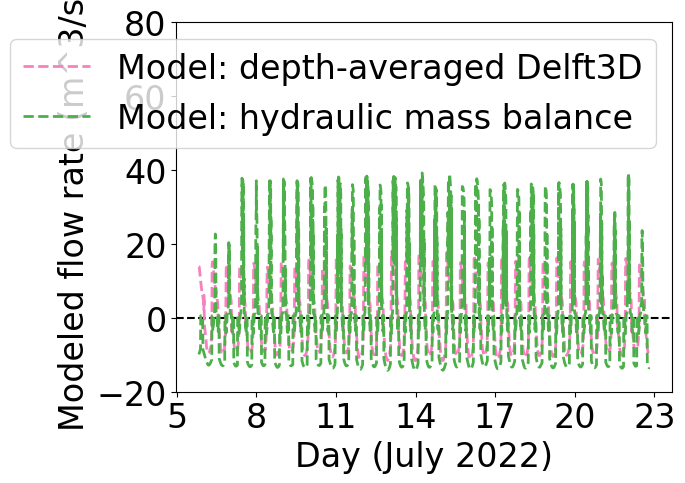

In [19]:
import CSV, Dates, DataFrames, LaTeXStrings
import PyPlot as plt
plt.pygui(true) # sets plots to popup instead of inline


kb_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/hr_heb_Verified_(m)_38834_dt360s_230418.csv", DataFrames.DataFrame)
mh_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/Delft3D_HR_Discharge.csv", DataFrames.DataFrame)
GMT_to_EDT = Dates.Hour(4)
kb_model.date_time = Dates.DateTime.(kb_model.date_time, "yyyy-mm-dd HH:MM:SS") - GMT_to_EDT # Convert to EDT here!
mh_model.Datetime = Dates.DateTime.(mh_model.Datetime, "m/d/y H:M") - GMT_to_EDT # Convert to EDT
kb_model.modeltime = Dates.Time.(kb_model.date_time)
mh_model.modeltime = Dates.Time.(mh_model.Datetime)
start_time = Dates.DateTime(2022, 7, 5, 0, 0, 0) # Dates.DateTime(2022, 7, 14, 2, 0, 0)
stop_time = Dates.DateTime(2022, 7, 25, 0, 0, 0) # Dates.DateTime(2022, 7, 14, 23, 0, 0)
kb_filt = kb_model[(kb_model.date_time.>= start_time) .& (kb_model.date_time.<= stop_time), :]
mh_filt = mh_model[(mh_model.Datetime.>= start_time) .& (mh_model.Datetime.<= stop_time), :]
# IRQIV_us_time = Dates.Time.(ATS_tst_vec_us)
# IRQIV_ds_time = Dates.Time.(ATS_tst_vec_ds)

# Colorblind-friendly pallette: https://gist.github.com/thriveth/8560036

# Define x-axis tick positions in 3-hour increments
tick_interval = Dates.Day(3) # Dates.Hour(3)
tick_positions = start_time:tick_interval:stop_time
# Format tick positions as strings for x-axis labels
tick_labels = Dates.format.(tick_positions, "d") # Dates.format.(tick_positions, "HH:MM")

# Plot results
plt.close("all")
fig, ax = plt.subplots()
ax.axhline(y=0, color = "black", linestyle = "--", label="_nolegend_")
# color1 = Colors.colorant"#377eb8"
ax.plot(mh_filt.Datetime, mh_filt."Total_Discharge_m3/s", c=:"#f781bf", linewidth = 2, linestyle="--")
ax.plot(kb_filt.date_time, kb_filt.Qtotal_m3s, c=:"#4daf4a", linewidth = 2, linestyle="--")
# ax.plot(TS_op_vec_us, Q_op_vec_us_scaled, c=:"#377eb8", linewidth = 4)
# ax.plot(TS_op_vec_ds, Q_op_vec_ds, c=:"#e41a1c", linewidth = 4)
# plt.ylabel(LaTeXStrings.LaTeXString("Modeled & measured volumetric flux (m^3/s)"))
plt.ylabel(LaTeXStrings.LaTeXString("Modeled flow rate (m^3/s)"))
# plt.xlabel("Hour (July 14, 2022)")
plt.xlabel("Day (July 2022)")
plt.legend(["Model: depth-averaged Delft3D","Model: hydraulic mass balance","IR-QIV: upstream outgoing tide", "IR-QIV: downstream incoming tide"], loc = "upper right")#  )
plt.ylim([-20, 80])
plt.xticks(tick_positions, tick_labels)  # Set x-axis tick positions and labels
plt.rc("font",size=24)
plt.gcf()

In [31]:
import CSV, Dates, DataFrames, LaTeXStrings
import PyPlot as plt
plt.pygui(true) # sets plots to popup instead of inline


kb_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/hr_heb_Verified_(m)_38834_dt360s_230418.csv", DataFrames.DataFrame)
mh_model = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/Modeling/Delft3D_HR_Discharge.csv", DataFrames.DataFrame)
GMT_to_EDT = Dates.Hour(4)
kb_model.date_time = Dates.DateTime.(kb_model.date_time, "yyyy-mm-dd HH:MM:SS") - GMT_to_EDT # Convert to EDT here!
mh_model.Datetime = Dates.DateTime.(mh_model.Datetime, "m/d/y H:M") - GMT_to_EDT # Convert to EDT
kb_model.modeltime = Dates.Time.(kb_model.date_time)
mh_model.modeltime = Dates.Time.(mh_model.Datetime)
start_time = Dates.DateTime(2022, 7, 14, 2, 0, 0)
stop_time = Dates.DateTime(2022, 7, 14, 23, 0, 0)
kb_filt = kb_model[(kb_model.date_time.>= start_time) .& (kb_model.date_time.<= stop_time), :]
mh_filt = mh_model[(mh_model.Datetime.>= start_time) .& (mh_model.Datetime.<= stop_time), :]
# IRQIV_us_time = Dates.Time.(ATS_tst_vec_us)
# IRQIV_ds_time = Dates.Time.(ATS_tst_vec_ds)

# Colorblind-friendly pallette: https://gist.github.com/thriveth/8560036

# Define x-axis tick positions in 3-hour increments
tick_interval = Dates.Hour(3)
tick_positions = start_time:tick_interval:stop_time
# Format tick positions as strings for x-axis labels
tick_labels = Dates.format.(tick_positions, "HH:MM")

# Plot results
plt.close("all")
fig, ax = plt.subplots()
ax.axhline(y=0, color = "black", linestyle = "--", label="_nolegend_")
# color1 = Colors.colorant"#377eb8"
ax.plot(mh_filt.Datetime, mh_filt."Total_Discharge_m3/s", c=:"#f781bf", linewidth = 2, linestyle="--")
ax.plot(kb_filt.date_time, kb_filt.Qtotal_m3s, c=:"#4daf4a", linewidth = 2, linestyle="--")
ax.plot(TS_op_vec_us, Q_op_vec_us_scaled, c=:"#377eb8", linewidth = 4)
ax.plot(TS_op_vec_ds, Q_op_vec_ds, c=:"#e41a1c", linewidth = 4)
# plt.ylabel(LaTeXStrings.LaTeXString("Modeled & measured volumetric flux (m^3/s)"))
plt.ylabel(LaTeXStrings.LaTeXString("Modeled flow rate (m^3/s)"))
# plt.xlabel("Hour (July 14, 2022)")
plt.xlabel("Day (July 2022)")
plt.legend(["Model: depth-averaged Delft3D","Model: hydraulic mass balance","IR-QIV: upstream outgoing tide", "IR-QIV: downstream incoming tide"], loc = "upper right")#  )
plt.ylim([-20, 80])
plt.xticks(tick_positions, tick_labels)  # Set x-axis tick positions and labels
plt.rc("font",size=24)
plt.show()